<a href="https://colab.research.google.com/github/23424022/Pengolahan-Citra-Digital/blob/main/UTS_PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

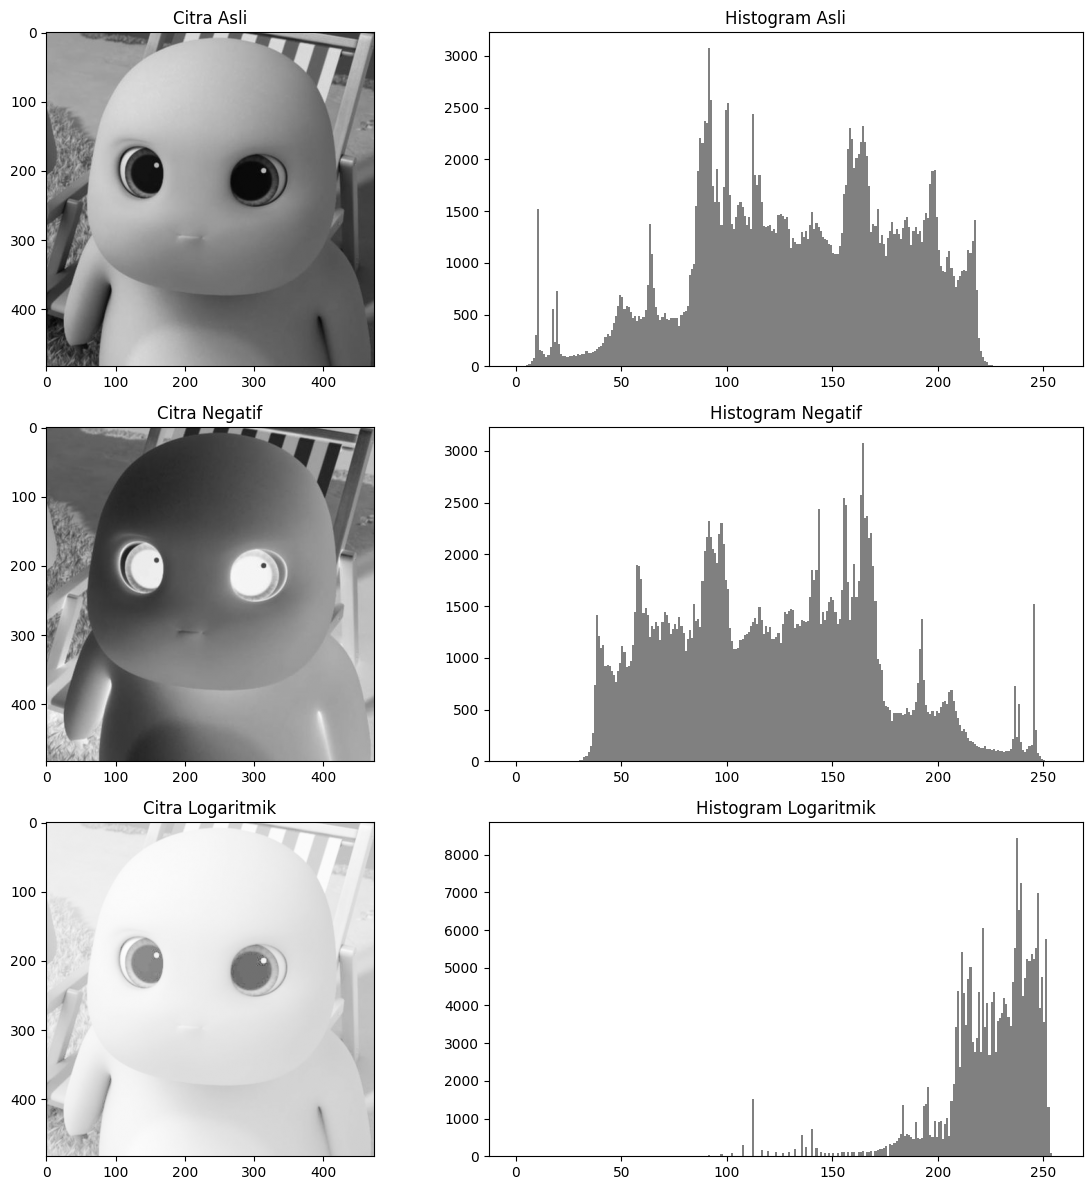

In [3]:
#SOAL NO. 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Langkah 1: Baca citra grayscale ---
# Pastikan Anda memiliki file gambar di direktori yang sama, ganti 'gambar_anda.jpg'
image_path = 'nailong.jpg'
F = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if F is None:
    print("Gambar tidak ditemukan. Pastikan path file benar.")
else:
    # --- Langkah 2: Terapkan Rumus ---

    # a. Transformasi Negatif: G = 255 - F
    G_negatif = 255 - F

    # b. Transformasi Logaritmik: G = c * log(1 + F)
    # Ubah tipe data F ke float untuk perhitungan logaritma agar tidak error/overflow
    F_float = np.float32(F)

    # Hitung nilai konstanta c: c = 255 / log(1 + max(F))
    c = 255 / np.log(1 + np.max(F_float))

    # Aplikasikan rumus logaritmik
    G_log_float = c * np.log(1 + F_float)

    # Ubah kembali ke tipe data uint8 (0-255) untuk ditampilkan sebagai gambar
    G_logaritmik = np.uint8(G_log_float)

    # --- Langkah 3: Tampilkan keempat gambar (citra & histogram) ---
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))

    # 1. Citra Asli
    axes[0, 0].imshow(F, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title('Citra Asli')
    axes[0, 1].hist(F.ravel(), bins=256, range=[0,256], color='gray')
    axes[0, 1].set_title('Histogram Asli')

    # 2. Citra Negatif
    axes[1, 0].imshow(G_negatif, cmap='gray', vmin=0, vmax=255)
    axes[1, 0].set_title('Citra Negatif')
    axes[1, 1].hist(G_negatif.ravel(), bins=256, range=[0,256], color='gray')
    axes[1, 1].set_title('Histogram Negatif')

    # 3. Citra Logaritmik
    axes[2, 0].imshow(G_logaritmik, cmap='gray', vmin=0, vmax=255)
    axes[2, 0].set_title('Citra Logaritmik')
    axes[2, 1].hist(G_logaritmik.ravel(), bins=256, range=[0,256], color='gray')
    axes[2, 1].set_title('Histogram Logaritmik')

    plt.tight_layout()
    plt.show()


--- Nilai Piksel Rata-rata ---
Original : 133.53
LPF      : 133.53
HPF      : 5.48
BPF      : 133.60


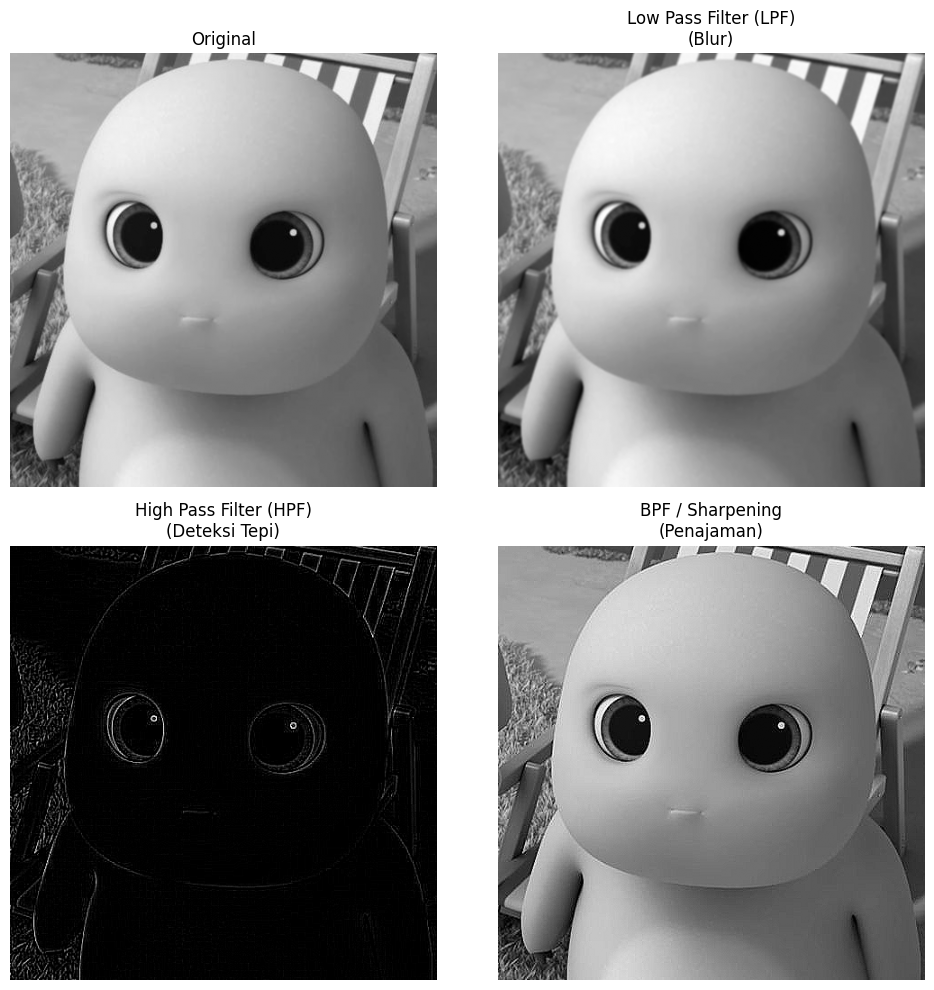

In [4]:
#SOAL NO. 2
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Langkah 1: Baca gambar ---
# Ganti 'gambar_anda.jpg' dengan nama file gambar Anda
image_path = 'nailong.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Gambar tidak ditemukan. Pastikan path file benar.")
else:
    # --- Langkah 2: Definisi Kernel ---
    # 1. Low Pass Filter (LPF) - Averaging/Blurring
    kernel_lpf = np.ones((3, 3), np.float32) / 9.0

    # 2. High Pass Filter (HPF) - Edge Detection
    kernel_hpf = np.array([[-1, -1, -1],
                           [-1,  8, -1],
                           [-1, -1, -1]], dtype=np.float32)

    # 3. Band Pass Filter (BPF) / Sharpening
    kernel_bpf = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float32)

    # --- Langkah 3: Terapkan Konvolusi ---
    # Kedalaman ddepth = -1 berarti citra hasil memiliki kedalaman yang sama dengan citra asli
    img_lpf = cv2.filter2D(img, -1, kernel_lpf)
    img_hpf = cv2.filter2D(img, -1, kernel_hpf)
    img_bpf = cv2.filter2D(img, -1, kernel_bpf)

    # --- Langkah 4: Hitung Nilai Piksel Rata-rata ---
    # Ini diperlukan untuk analisa bagian 1
    mean_orig = np.mean(img)
    mean_lpf = np.mean(img_lpf)
    mean_hpf = np.mean(img_hpf)
    mean_bpf = np.mean(img_bpf)

    print("--- Nilai Piksel Rata-rata ---")
    print(f"Original : {mean_orig:.2f}")
    print(f"LPF      : {mean_lpf:.2f}")
    print(f"HPF      : {mean_hpf:.2f}")
    print(f"BPF      : {mean_bpf:.2f}")

    # --- Langkah 5: Tampilkan Keempat Gambar ---
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    axes[0, 0].imshow(img, cmap='gray')
    axes[0, 0].set_title('Original')

    axes[0, 1].imshow(img_lpf, cmap='gray')
    axes[0, 1].set_title('Low Pass Filter (LPF)\n(Blur)')

    axes[1, 0].imshow(img_hpf, cmap='gray')
    axes[1, 0].set_title('High Pass Filter (HPF)\n(Deteksi Tepi)')

    axes[1, 1].imshow(img_bpf, cmap='gray')
    axes[1, 1].set_title('BPF / Sharpening\n(Penajaman)')

    for ax in axes.flat:
        ax.axis('off') # Sembunyikan sumbu koordinat

    plt.tight_layout()
    plt.show()